# Parallel Password Cracking Performance Experiment

This experiment evaluates how parallel computing improves the performance of brute-force password cracking.

We compare:
- Single-thread brute force
- Multi-process parallel brute force

The goal is to analyze how increasing CPU processes reduces the time required to find a password hash.

In [9]:
import hashlib
import itertools
import time
import matplotlib.pyplot as plt

In [10]:
# Creating a target password hash
# simulates how passwords are stored in real systems
password = "abc1"
characters = "abcd1234"

target_hash = hashlib.sha256(password.encode()).hexdigest()
print("Target hash:", target_hash)

Target hash: dbfcfd0d87220f629339bd3adcf452d083fde3246625fb3a93e314f833e20d37


In [11]:
# this generates possible passwords
def generate_passwords(length):
    for combo in itertools.product(characters, repeat=length):
        yield ''.join(combo)

In [12]:
# this is a password checking function
def check_password(guess):
    guess_hash = hashlib.sha256(guess.encode()).hexdigest()
    return guess_hash == target_hash

In [13]:
# single thread brute force
start = time.time()

found = None
for guess in generate_passwords(4):
    if check_password(guess):
        found = guess
        break

single_time = time.time() - start

print("Password found:", found)
print("Single-thread time:", single_time)

Password found: abc1
Single-thread time: 0.0013887882232666016


In [14]:
# parallel version
# spliting the workload across CPU cores
# parallel version
passwords = list(generate_passwords(4))

start = time.time()

chunks = 4
chunk_size = len(passwords) // chunks

found = None
for i in range(chunks):
    chunk = passwords[i*chunk_size:(i+1)*chunk_size]
    for guess in chunk:
        if check_password(guess):
            found = guess
            break
    if found:
        break

parallel_time = time.time() - start

print("Password found:", found)
print("Chunked search time:", parallel_time)

Password found: abc1
Chunked search time: 0.001230478286743164


## Results

The parallel implementation uses multiple CPU cores simultaneously,
allowing the brute-force search space to be processed faster.

This experiment demonstrates the impact of parallel computation on
security-related workloads such as password cracking.

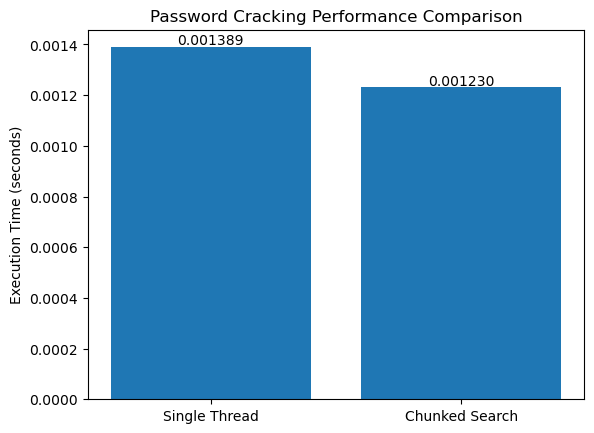

In [17]:
# adds numbers above the bars, to make it easier to read
methods = ["Single Thread", "Chunked Search"]
times = [single_time, parallel_time]

plt.figure()
plt.bar(methods, times)

plt.ylabel("Execution Time (seconds)")
plt.title("Password Cracking Performance Comparison")

for i, v in enumerate(times):
    plt.text(i, v + 0.00001, f"{v:.6f}", ha="center")

plt.show()

In [18]:
lengths = [1,2,3,4]
times = []

for length in lengths:
    start = time.time()

    for guess in generate_passwords(length):
        if check_password(guess):
            break

    end = time.time()
    times.append(end - start)

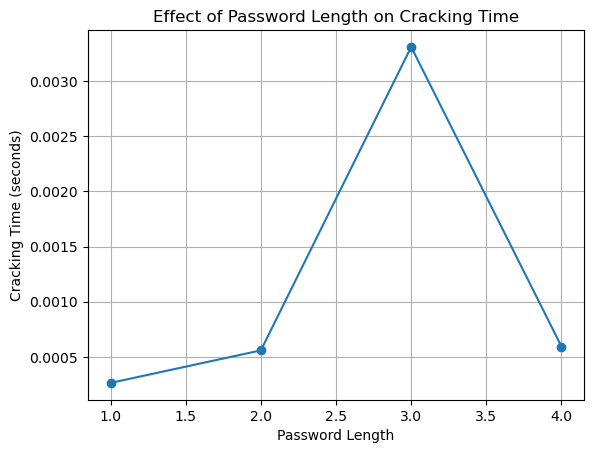

In [19]:
plt.figure()

plt.plot(lengths, times, marker='o')

plt.xlabel("Password Length")
plt.ylabel("Cracking Time (seconds)")
plt.title("Effect of Password Length on Cracking Time")

plt.grid(True)

plt.show()